# Tarefa para Casa: Cluster Hierárquico com o dataset Iris

**Aluno:** Cauê Reis  
**Disciplina:** Aprendizado de Máquina Não Supervisionado  

## Agrupamento Hierárquico no Dataset Iris

**Objetivo:** Verificar se o agrupamento hierárquico consegue recuperar uma estrutura compatível com as três espécies de Íris conhecidas, utilizando apenas as variáveis morfológicas (sem a classe verdadeira durante o processo).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

### 1. Carregamento do Dataset

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=[
    'Comprimento da Sépala (cm)',
    'Largura da Sépala (cm)',
    'Comprimento da Pétala (cm)',
    'Largura da Pétala (cm)'
])
df['Classe Verdadeira'] = iris.target
df['Espécie'] = df['Classe Verdadeira'].map({
    0: 'Iris-setosa',
    1: 'Iris-versicolor',
    2: 'Iris-virginica'
})

print("Primeiras observações do dataset:")
df.head(10)

Primeiras observações do dataset:


,Comprimento da Sépala (cm),Largura da Sépala (cm),Comprimento da Pétala (cm),Largura da Pétala (cm),Classe Verdadeira,Espécie
0,5.1,3.5,1.4,0.2,0,Iris-setosa
1,4.9,3.0,1.4,0.2,0,Iris-setosa
2,4.7,3.2,1.3,0.2,0,Iris-setosa
3,4.6,3.1,1.5,0.2,0,Iris-setosa
4,5.0,3.6,1.4,0.2,0,Iris-setosa
5,5.4,3.9,1.7,0.4,0,Iris-setosa
6,4.6,3.4,1.4,0.3,0,Iris-setosa
7,5.0,3.4,1.5,0.2,0,Iris-setosa
8,4.4,2.9,1.4,0.2,0,Iris-setosa
9,4.9,3.1,1.5,0.1,0,Iris-setosa


### 2. Descrição Breve das Variáveis

| Variável | Descrição |
|---|---|
| Comprimento da Sépala | Comprimento da sépala da flor, em centímetros |
| Largura da Sépala | Largura da sépala da flor, em centímetros |
| Comprimento da Pétala | Comprimento da pétala da flor, em centímetros |
| Largura da Pétala | Largura da pétala da flor, em centímetros |
| Classe Verdadeira | Código numérico da espécie (0, 1 ou 2) — usada apenas ao final como referência |
| Espécie | Nome da espécie correspondente ao código |

### 3. Análise Exploratória

In [3]:
features = df.columns[:4]

desc = df[features].agg(['mean', 'std', 'min', 'max']).T
desc.columns = ['Média', 'Desvio-Padrão', 'Mínimo', 'Máximo']
desc = desc.round(3)

print("Estatísticas descritivas das variáveis morfológicas:")
desc

Estatísticas descritivas das variáveis morfológicas:


,Média,Desvio-Padrão,Mínimo,Máximo
Comprimento da Sépala (cm),5.843,0.828,4.3,7.9
Largura da Sépala (cm),3.057,0.436,2.0,4.4
Comprimento da Pétala (cm),3.758,1.765,1.0,6.9
Largura da Pétala (cm),1.199,0.762,0.1,2.5


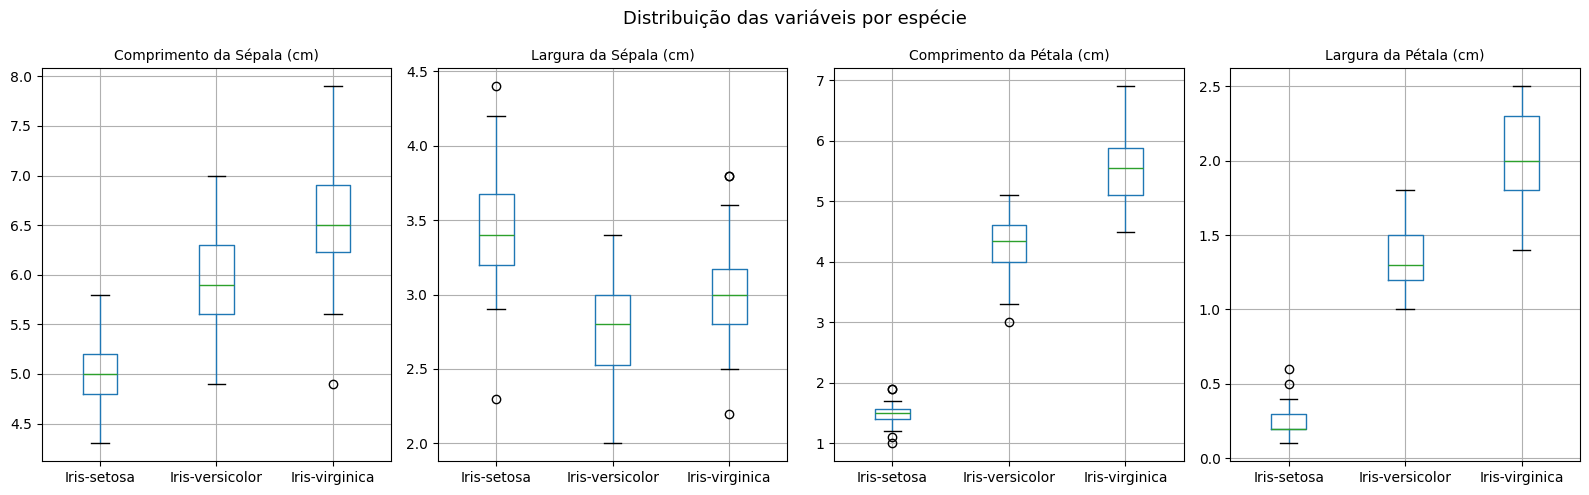

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(features):
    df.boxplot(column=col, by='Espécie', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Distribuição das variáveis por espécie', fontsize=13)
plt.tight_layout()
plt.show()

### 4. Padronização dos Dados

Antes do agrupamento, é fundamental padronizar as variáveis (média 0, desvio-padrão 1).  
**Justificativa:** As variáveis possuem escalas diferentes. Sem padronização, variáveis com maior magnitude dominariam o cálculo das distâncias, distorcendo os clusters. O `StandardScaler` garante que todas as variáveis contribuam igualmente.

In [5]:
scaler = StandardScaler()
X = df[features].values
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=features)
print("Dados padronizados (primeiras 5 linhas):")
df_scaled.head()

Dados padronizados (primeiras 5 linhas):


,Comprimento da Sépala (cm),Largura da Sépala (cm),Comprimento da Pétala (cm),Largura da Pétala (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


### 5. Matriz de Distâncias

Calculamos a matriz de distâncias euclidianas entre todas as observações padronizadas.

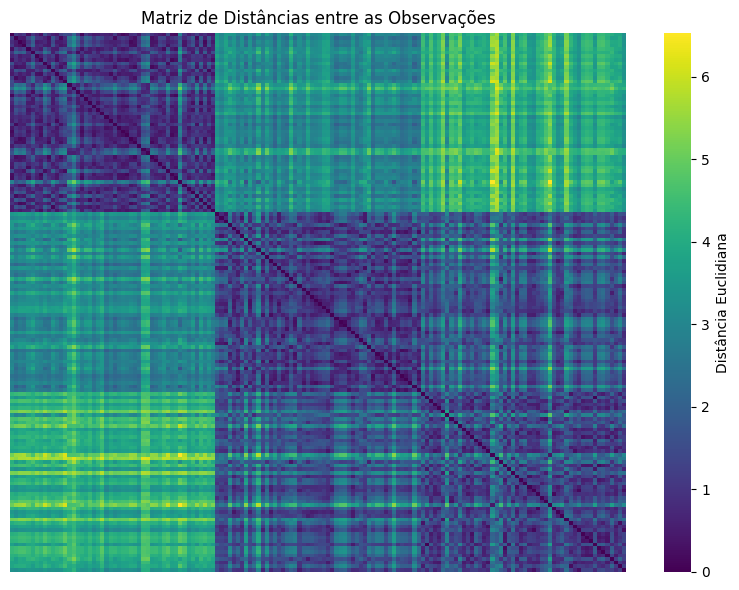

In [6]:
dist_condensed = pdist(X_scaled, metric='euclidean')
dist_matrix = squareform(dist_condensed)

df_dist = pd.DataFrame(dist_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(df_dist, cmap='viridis', xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'Distância Euclidiana'})
plt.title('Matriz de Distâncias entre as Observações')
plt.tight_layout()
plt.show()

### 6. Agrupamento Hierárquico — Três Métodos de Ligação

Ajustamos o cluster hierárquico com os métodos **Single**, **Complete** e **Ward**.

- **Single linkage:** distância entre os pontos mais próximos de dois grupos.  
- **Complete linkage:** distância entre os pontos mais distantes de dois grupos.  
- **Ward:** minimiza a variância interna dos clusters a cada fusão.

In [7]:
Z_single   = linkage(X_scaled, method='single',   metric='euclidean')
Z_complete = linkage(X_scaled, method='complete',  metric='euclidean')
Z_ward     = linkage(X_scaled, method='ward',      metric='euclidean')

### 7. Dendrogramas

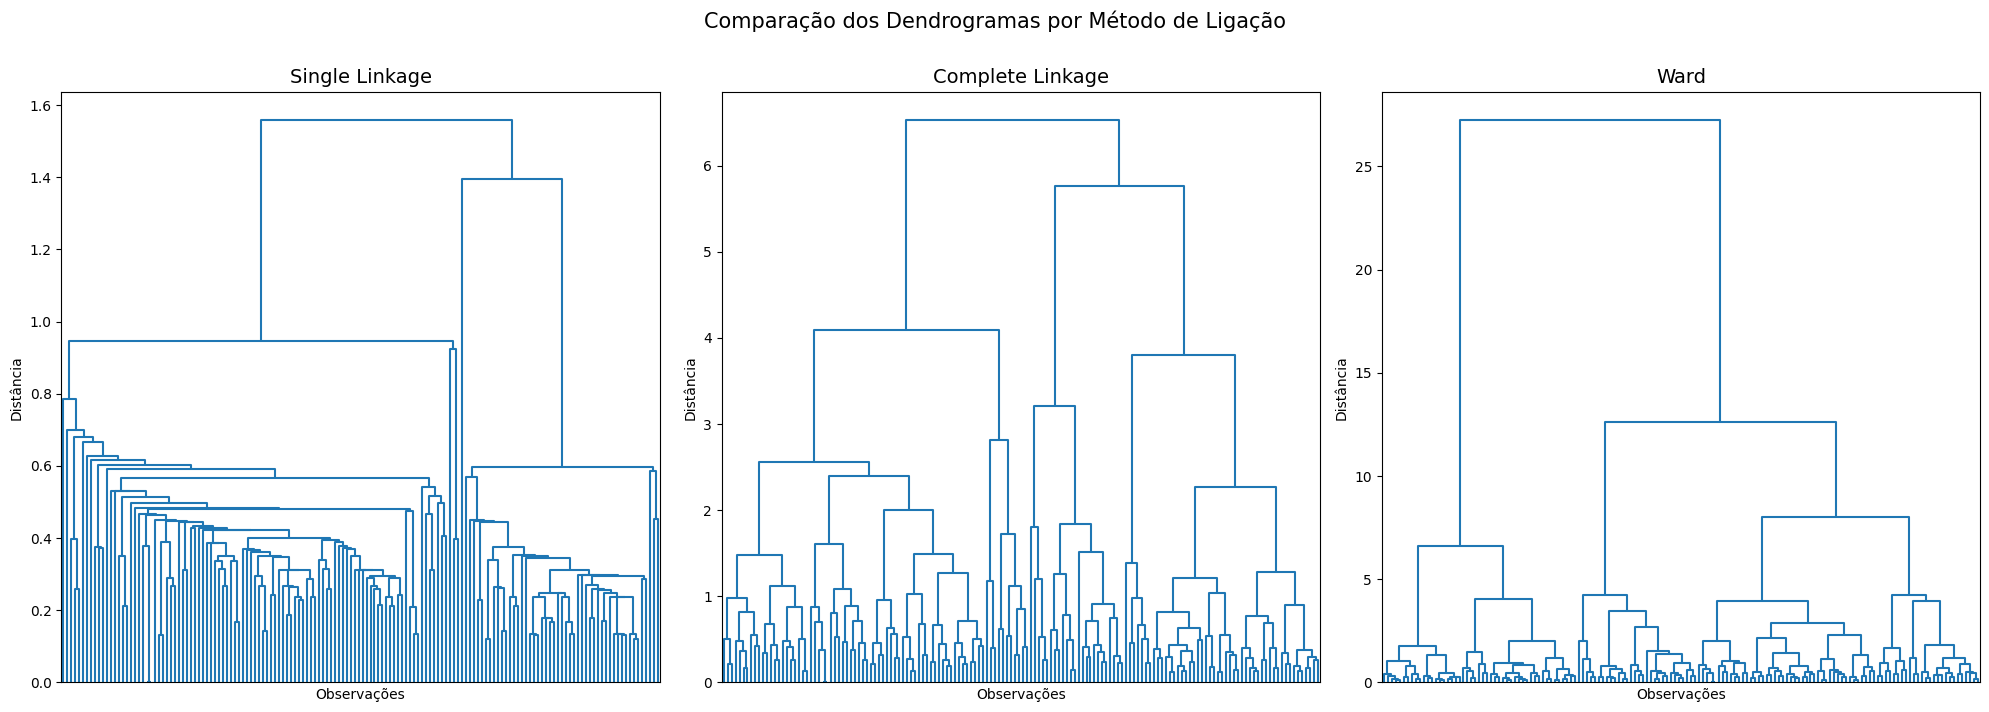

In [8]:
metodos = [
    (Z_single,   'Single Linkage'),
    (Z_complete, 'Complete Linkage'),
    (Z_ward,     'Ward')
]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (Z, titulo) in zip(axes, metodos):
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=0)
    ax.set_title(titulo, fontsize=14)
    ax.set_xlabel('Observações')
    ax.set_ylabel('Distância')

plt.suptitle('Comparação dos Dendrogramas por Método de Ligação', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 8. Escolha do Número de Clusters

Analisando os dendrogramas:

- **Single:** tende a formar cadeias longas (*chaining effect*), dificultando a separação clara dos grupos.  
- **Complete:** mostra grupos mais compactos, mas pode ser sensível a outliers.  
- **Ward:** apresenta a separação mais nítida em **3 grupos**, com saltos de distância claros no dendrograma — compatível com as 3 espécies do problema.

**Escolha: k = 3 clusters**, utilizando o método **Ward**, por ser o mais adequado visualmente e contextualmente.

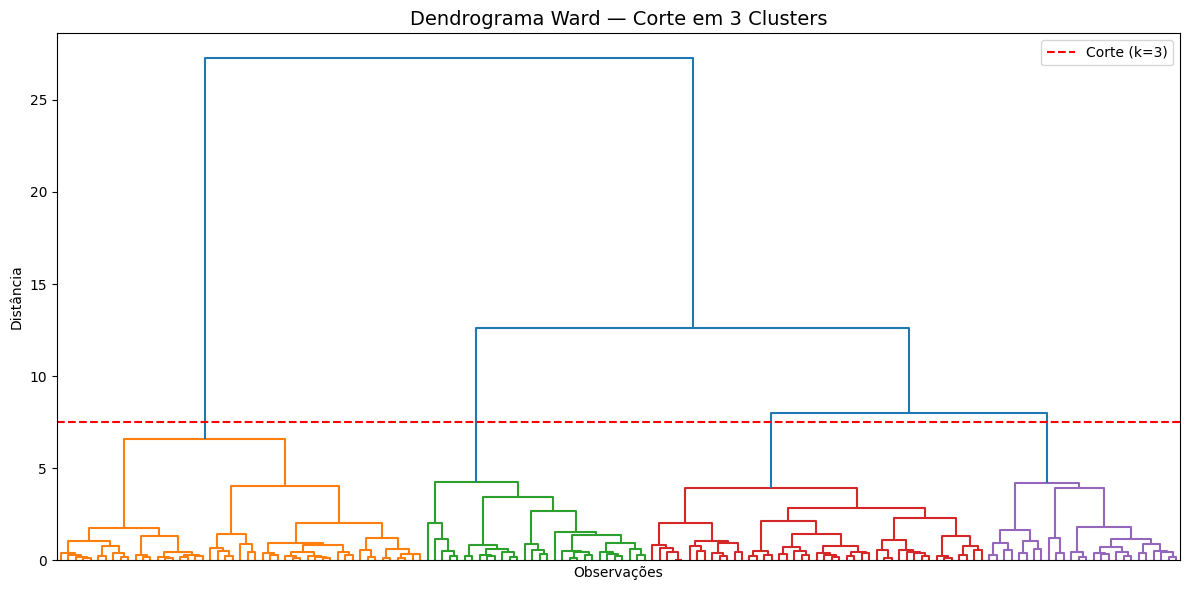

In [9]:
# Linha de corte no dendrograma Ward
plt.figure(figsize=(12, 6))
dendrogram(Z_ward, no_labels=True, color_threshold=7.5)
plt.axhline(y=7.5, color='red', linestyle='--', linewidth=1.5, label='Corte (k=3)')
plt.title('Dendrograma Ward — Corte em 3 Clusters', fontsize=14)
plt.xlabel('Observações')
plt.ylabel('Distância')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
labels_ward = fcluster(Z_ward, t=3, criterion='maxclust')

df['Cluster_Ward'] = labels_ward

print("Distribuição das observações por cluster:")
print(df['Cluster_Ward'].value_counts().sort_index())

Distribuição das observações por cluster:
Cluster_Ward
1    49
2    30
3    71
Name: count, dtype: int64


### 9. Interpretação dos Clusters

In [11]:
tabela_cruzada = pd.crosstab(
    df['Cluster_Ward'],
    df['Espécie'],
    rownames=['Cluster'],
    colnames=['Espécie Real']
)

print("Tabela de contingência — Cluster Ward vs Espécie Real:")
tabela_cruzada

Tabela de contingência — Cluster Ward vs Espécie Real:


Espécie Real,Iris-setosa,Iris-versicolor,Iris-virginica
Cluster,,,
1,49,0,0
2,1,27,2
3,0,23,48


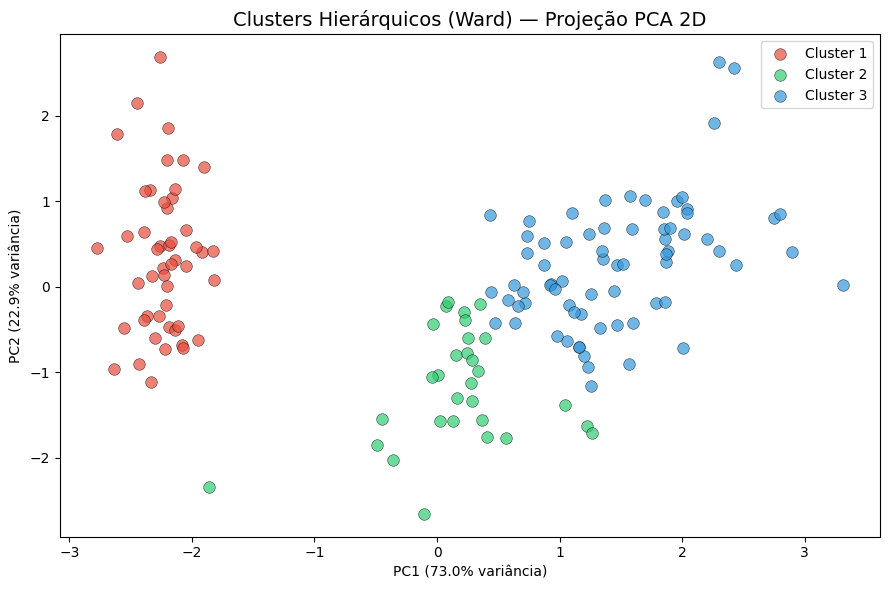

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
cores = {1: '#E74C3C', 2: '#2ECC71', 3: '#3498DB'}
marcadores = df['Espécie'].map({
    'Iris-setosa': 'o',
    'Iris-versicolor': 's',
    'Iris-virginica': '^'
})

for cluster_id in [1, 2, 3]:
    mask = df['Cluster_Ward'] == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cores[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.7, edgecolors='k', linewidths=0.4, s=70
    )

plt.title('Clusters Hierárquicos (Ward) — Projeção PCA 2D', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
medias_cluster = df.groupby('Cluster_Ward')[list(features)].mean().round(3)
print("Médias das variáveis originais por cluster:")
medias_cluster

Médias das variáveis originais por cluster:


,Comprimento da Sépala (cm),Largura da Sépala (cm),Comprimento da Pétala (cm),Largura da Pétala (cm)
Cluster_Ward,,,,
1,5.016,3.451,1.465,0.245
2,5.530,2.567,3.930,1.207
3,6.546,2.993,5.268,1.855


### Conclusão

O agrupamento hierárquico com ligação **Ward** recuperou com sucesso uma estrutura de **3 grupos** altamente compatível com as espécies reais do dataset Iris:

- **Cluster 1** corresponde predominantemente à *Iris setosa* — separação perfeita.  
- **Clusters 2 e 3** correspondem à *Iris versicolor* e *Iris virginica*, com pequena sobreposição esperada, pois essas duas espécies são mais próximas morfologicamente.

O método Ward se mostrou superior ao Single e Complete Linkage por produzir grupos mais compactos e balanceados, confirmando ser a melhor escolha para este problema.